# Imports 

### Import Libraries

In [31]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(sys.path[:3])

['c:\\Users\\m.ahmadi\\Desktop\\FinalProject', 'C:\\Users\\mo.ahmadi\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\mo.ahmadi\\AppData\\Local\\Programs\\Python\\Python313\\DLLs']


In [32]:
print(sys.path)

['c:\\Users\\m.ahmadi\\Desktop\\FinalProject', 'C:\\Users\\mo.ahmadi\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\mo.ahmadi\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\mo.ahmadi\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\mo.ahmadi\\AppData\\Local\\Programs\\Python\\Python313', 'c:\\Users\\m.ahmadi\\Desktop\\FinalProject\\venv', '', 'c:\\Users\\m.ahmadi\\Desktop\\FinalProject\\venv\\Lib\\site-packages']


In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from env.loan_env import LoanEnv

### Import Dataset & Build env

In [34]:
PATH = r"C:\Users\m.ahmadi\Desktop\FinalProject\notebooks\df_cleaned.csv"

df_raw = pd.read_csv(PATH)

train_idx, test_idx = train_test_split(
    np.arange(len(df_raw)),
    test_size=0.2,
    random_state=42,
    shuffle=True
)

train_df = df_raw.iloc[train_idx].reset_index(drop=True)
test_df = df_raw.iloc[test_idx].reset_index(drop=True)

print("Train:", len(train_df))
print("Test :", len(test_df))

Train: 80000
Test : 20001


In [35]:
FEATURE_COLUMNS = [
    "MountlyIncome",
    "IncomeScore",
    "JobScore",
    "AssetScore",
    "TotalCustomerScore",
    "TotalFacilities",
    "DebtAmount",
    "OriginAmount",
    "LoanCounts",
    "DebtRatio",
    "DebtPerLoan",
    "Has_No_History",
    "Employed",
    "Score_Min",
    "Score_Max",
    "Risk_Min",
    "Risk_Max",
    "Risk",
]

train_features = train_df.copy()

train_features["Risk"] = (
    train_features["Risk_Min"] +
    train_features["Risk_Max"]
) / 2

scaler = StandardScaler()

scaler.fit(
    train_features[FEATURE_COLUMNS]
)

StandardScaler()

In [36]:
env = LoanEnv(test_df, scaler)

# Transition Model Behaviour Analysis

In [37]:
actions = [
    0,
    100_000_000,
    200_000_000,
    300_000_000,
    400_000_000,
    500_000_000,
]

rows = []

for i in range(len(test_df)):

    customer = env._row_to_customer_state(
        test_df.iloc[i]
    )

    risk_before = customer.risk

    for amount in actions:

        outcome = env.simulator.simulate(
            customer=customer.copy(),
            approved_unsecured_amount=amount
        )

        rows.append({
            "customer": i,
            "loan": amount,

            "risk_before": risk_before,
            "risk_after": outcome.next_state.risk,

            "delta_risk":
                outcome.next_state.risk - risk_before,

            "pd_before":
                env.simulator._calculate_default_probability(
                    env.simulator._estimate_hazard(customer)
                ),

            "pd_after":
                outcome.probability_of_default,

            "debt_ratio_change": (
                outcome.next_state.debt_ratio
                - customer.debt_ratio
                ),

            "debt_per_loan_change": (
                outcome.next_state.debt_per_loan
                - customer.debt_per_loan
                ),
        })

transition_df = pd.DataFrame(rows)

transition_df.shape

(120006, 9)

In [38]:
transition_df.groupby("loan")[
    ["risk_after", "delta_risk", "pd_after"]
].agg([
    "mean",
    "median",
    "std",
    "min",
    "max"
])

risk_after                                 delta_risk            \
                mean median        std   min     max       mean    median   
loan                                                                        
0          28.033936  20.65  25.297357  1.55   96.45   0.000000  0.000000   
100000000  28.828899  22.65  25.785406  0.00  100.00   0.794963  0.057326   
200000000  29.023238  22.65  25.826629  0.00  100.00   0.989302  0.183214   
300000000  29.205348  22.65  25.881499  0.00  100.00   1.171412  0.289274   
400000000  29.374790  22.65  25.936108  0.00  100.00   1.340854  0.392578   
500000000  29.533575  22.65  25.985838  0.00  100.00   1.499639  0.483679   

                                   pd_after                                \
                std    min    max      mean    median       std       min   
loan                                                                        
0          0.000000   0.00   0.00  0.014521  0.003698  0.022756  0.000830   
100000000  4.927489 -96.45  98.45  0.015121  0.004308  0.023236  0.000734   
200000000  5.130565 -96.45  98.45  0.015240  0.004308  0.023321  0.000734   
300000000  5.427234 -96.45  98.45  0.015356  0.004308  0.023417  0.000734   
400000000  5.717757 -96.45  98.45  0.015463  0.004308  0.023506  0.000734   
500000000  5.980704 -96.45  98.45  0.015564  0.004308  0.023587  0.000734   

                     
                max  
loan                 
0          0.081834  
100000000  0.082842  
200000000  0.082842  
300000000  0.082842  
400000000  0.082842  
500000000  0.082842

In [39]:
clipping_rate = (
    transition_df
    .groupby("loan")["risk_after"]
    .apply(lambda x: ((x == 0) | (x == 100)).mean())
)

clipping_rate

loan
0            0.00000
100000000    0.00580
200000000    0.00655
300000000    0.00730
400000000    0.00840
500000000    0.00925
Name: risk_after, dtype: float64

In [40]:
extreme_500 = transition_df[
    (transition_df["loan"] == 500_000_000) &
    (
        (transition_df["risk_after"] == 0) |
        (transition_df["risk_after"] == 100)
    )
]

extreme_500[
    [
        "customer",
        "risk_before",
        "risk_after",
        "delta_risk",
        "pd_before",
        "pd_after"
    ]
].head(20)

,customer,risk_before,risk_after,delta_risk,pd_before,pd_after
1919,319,61.75,100.0,38.25,0.047004,0.082842
2027,337,29.10,100.0,70.90,0.006982,0.082842
2591,431,20.65,100.0,79.35,0.003698,0.082842
3041,506,96.45,100.0,3.55,0.081834,0.082842
3767,627,96.45,100.0,3.55,0.081834,0.082842
4049,674,14.10,100.0,85.90,0.002229,0.082842
4601,766,9.40,100.0,90.60,0.001543,0.082842
5915,985,96.45,100.0,3.55,0.081834,0.082842
6017,1002,39.30,100.0,60.70,0.014323,0.082842
6239,1039,91.00,100.0,9.00,0.079691,0.082842


In [41]:
transition_df[
    (transition_df["loan"] == 500_000_000) &
    (transition_df["risk_after"] == 100)
][[
    "risk_before",
    "risk_after",
    "delta_risk",
    "debt_ratio_change",
    "debt_per_loan_change"
]].head(20)

,risk_before,risk_after,delta_risk,debt_ratio_change,debt_per_loan_change
1919,61.75,100.0,38.25,0.531228,2.499496e+08
2027,29.10,100.0,70.90,0.721056,2.486774e+08
2591,20.65,100.0,79.35,0.980392,2.500000e+08
3041,96.45,100.0,3.55,0.602764,2.446633e+08
3767,96.45,100.0,3.55,0.249999,2.499966e+08
4049,14.10,100.0,85.90,0.850340,2.500000e+08
4601,9.40,100.0,90.60,0.862403,2.491200e+08
5915,96.45,100.0,3.55,0.414238,1.526644e+08
6017,39.30,100.0,60.70,0.909091,2.500000e+08
6239,91.00,100.0,9.00,0.554219,2.500000e+08


In [42]:
customer = test_df.iloc[1919]

customer_state = env._row_to_customer_state(customer)

print("Debt:", customer_state.debt)
print("Loan count:", customer_state.loan_count)
print("Debt per loan:", customer_state.debt_per_loan)
print("Debt ratio:", customer_state.debt_ratio)

Debt: 3895973292.0
Loan count: 2
Debt per loan: 1947986646.0
Debt ratio: 1.207986776487805


In [43]:
amount = 500_000_000

outcome = env.simulator.simulate(
    customer_state.copy(),
    approved_unsecured_amount=amount
)

next_customer = outcome.next_state

print("BEFORE")
print("debt:", customer_state.debt)
print("loan_count:", customer_state.loan_count)
print("debt_per_loan:", customer_state.debt_per_loan)
print("debt_ratio:", customer_state.debt_ratio)

print("\nAFTER")
print("debt:", next_customer.debt)
print("loan_count:", next_customer.loan_count)
print("debt_per_loan:", next_customer.debt_per_loan)
print("debt_ratio:", next_customer.debt_ratio)

BEFORE
debt: 3895973292.0
loan_count: 2
debt_per_loan: 1947986646.0
debt_ratio: 1.207986776487805

AFTER
debt: 4395973292.0
loan_count: 3
debt_per_loan: 1465324430.6666667
debt_ratio: 1.2383023357746479


In [44]:
debt_per_loan_change = (
    next_customer.debt_per_loan -
    customer_state.debt_per_loan
) / customer_state.debt_per_loan

debt_ratio_change = (
    next_customer.debt_ratio -
    customer_state.debt_ratio
)

print("debt_per_loan_change:", debt_per_loan_change)
print("debt_ratio_change:", debt_ratio_change)

debt_per_loan_change: -0.24777490971225746
debt_ratio_change: 0.03031555928684293


In [45]:
customer = env.current_customer.copy()

outcome = env.simulator.simulate(
    customer,
    approved_unsecured_amount=0
)

print(customer.debt)
print(outcome.next_state.debt)

print(customer.loan_count)
print(outcome.next_state.loan_count)

print(customer.risk)
print(outcome.next_state.risk)

AttributeError: 'NoneType' object has no attribute 'copy'

In [ ]:
results.groupby("approved_amount")[
    [
        "has_no_history",
        "total_facilities",
        "total_customer_score",
        "probability_of_default",
        "previous_risk"
    ]
].mean()

,has_no_history,total_facilities,total_customer_score,probability_of_default,previous_risk
approved_amount,,,,,
0.0,0.065401,9.836076e+08,51.782700,0.007928,21.956329
100000000.0,0.043491,8.420510e+08,45.055846,0.016152,27.649463
200000000.0,0.022767,1.131156e+09,55.882662,0.010736,19.336778
300000000.0,0.450177,1.996156e+08,23.755438,0.021247,33.397850
400000000.0,0.094697,1.200568e+09,57.310606,0.023407,30.335038
500000000.0,0.004810,9.319866e+08,48.917189,0.014453,25.913122


### Visuallization

In [ ]:
import torch
import pandas as pd

def get_q_values(model, env, n_samples=20):

    rows = []

    for _ in range(n_samples):

        obs, _ = env.reset()

        obs_tensor = torch.tensor(
            obs,
            dtype=torch.float32,
            device=model.device
        ).unsqueeze(0)

        with torch.no_grad():
            q = model.q_net(obs_tensor).cpu().numpy().flatten()

        customer = env.current_customer.copy()

        outcome = env.simulator.simulate(
            customer=customer,
            approved_unsecured_amount=approved_amount
        )

        rows.append({
            "Q_0": q[0],
            "Q_100": q[1],
            "Q_200": q[2],
            "Q_300": q[3],
            "Q_400": q[4],
            "Q_500": q[5],
            "BestAction": env.actions[q.argmax()],
            "Risk": env.current_customer.risk,
            "Facility": env.current_customer.total_facilities,
            "Need": env.current_customer.total_customer_score,
            "History": env.current_customer.has_no_history,
            "Score": env.current_customer.total_customer_score,
            "PD": outcome.probability_of_default,
            "Observation": obs.copy()
        })

    return pd.DataFrame(rows)

In [ ]:
q_df = get_q_values(model, env, 100)

q_df.head()

,Q_0,Q_100,Q_200,Q_300,Q_400,Q_500,BestAction,Risk,Facility,Need,History,Score,PD,Observation
0,6.669776e+07,2.739795e+08,5.071291e+08,3.852351e+08,4.847736e+08,6.707415e+08,500000000.0,29.10,1.360000e+09,68.0,False,68.0,0.007216,"[4.5e+08, 54.0, 18.0, 18.0, 68.0, 1.36e+09, 6...."
1,-2.681381e-02,4.472665e-01,1.250178e-01,-7.257611e-03,-1.530293e-01,-2.484431e-01,100000000.0,14.10,0.000000e+00,24.0,False,24.0,0.002338,"[0.0, 0.0, 0.0, 0.0, 24.0, 0.0, 3.3867475e+08,..."
2,-2.681381e-02,4.472665e-01,1.250178e-01,-7.257611e-03,-1.530293e-01,-2.484431e-01,100000000.0,6.15,0.000000e+00,30.0,False,30.0,0.001206,"[0.0, 0.0, 0.0, 0.0, 30.0, 0.0, 5.0103037e+08,..."
3,6.139414e+06,2.521934e+07,4.668036e+07,3.546022e+07,4.462257e+07,6.174060e+07,500000000.0,1.55,0.000000e+00,30.0,False,30.0,0.000930,"[0.0, 0.0, 0.0, 0.0, 30.0, 0.0, 1.0789764e+09,..."
4,1.456137e+07,5.981484e+07,1.107158e+08,8.410402e+07,1.058351e+08,1.464354e+08,500000000.0,3.95,0.000000e+00,30.0,False,30.0,0.001059,"[0.0, 0.0, 0.0, 0.0, 30.0, 0.0, 2.8879299e+09,..."


In [ ]:
q_df.to_csv("q_df_scaled_version.csv")

In [ ]:
q_df.describe()

,Q_0,Q_100,Q_200,Q_300,Q_400,Q_500,BestAction,Risk,Facility,Need,Score,PD
count,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,1.000000e+02,100.0,100.000000,1.000000e+02,100.000000,100.000000,100.000000
mean,4.308726e+06,3.694309e+07,7.538043e+07,6.046229e+07,7.458084e+07,1.048332e+08,257000016.0,25.536500,7.770000e+08,43.180000,43.180000,0.015952
std,5.707089e+07,1.820657e+08,3.309575e+08,2.506814e+08,3.158319e+08,4.367422e+08,168927104.0,23.851938,9.230368e+08,24.862604,24.862604,0.023506
min,-2.780536e+08,-2.468652e+08,-6.387927e+07,-7.257611e-03,-6.508062e+07,-8.426660e+07,100000000.0,1.550000,0.000000e+00,6.000000,6.000000,0.000766
25%,-4.415794e+02,-1.928109e+01,1.250178e-01,-7.257611e-03,-9.189531e+01,-2.484431e-01,100000000.0,6.150000,0.000000e+00,24.000000,24.000000,0.001259
50%,-2.681381e-02,4.472665e-01,1.250178e-01,8.485076e+02,-1.530293e-01,-2.484431e-01,300000000.0,20.650000,4.200000e+08,42.000000,42.000000,0.005348
75%,-2.681381e-02,4.472665e-01,1.119487e+02,1.921058e+06,2.925837e+06,4.562578e+06,500000000.0,39.300000,1.305000e+09,65.250000,65.250000,0.014513
max,3.967885e+08,1.629918e+09,3.016937e+09,2.291783e+09,2.883943e+09,3.990276e+09,500000000.0,96.450000,3.680000e+09,92.000000,92.000000,0.082842


In [ ]:
print(env.current_customer.to_array())

[0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 3.0000000e+01
 0.0000000e+00 1.0789764e+09 1.6913572e+09 4.0000000e+00 5.2514845e-01
 2.6974410e+08 0.0000000e+00 0.0000000e+00 6.8000000e+02 9.0000000e+02
 0.0000000e+00 3.0999999e+00 1.5500000e+00]


In [ ]:
q_df[
    ["Q_0","Q_100","Q_200","Q_300","Q_400","Q_500"]
].drop_duplicates().shape

(39, 6)

In [ ]:
action_map = {
    "Q_0": 0,
    "Q_100": 100_000_000,
    "Q_200": 200_000_000,
    "Q_300": 300_000_000,
    "Q_400": 400_000_000,
    "Q_500": 500_000_000,
}

q_df["BestAction"] = (
    q_df[["Q_0","Q_100","Q_200","Q_300","Q_400","Q_500"]]
    .idxmax(axis=1)
    .map(action_map)
)

In [ ]:
q_analysis = q_df.groupby("BestAction").agg({
    "Risk": ["mean", "std"],
    "Need": ["mean", "std"],
    "Facility": ["mean", "std"],
    "PD": ["mean", "std"],
})

In [ ]:
q_analysis.to_csv("q_analysis.csv")

### Sensitivity Analysis

In [ ]:
rows = []

customer = env.current_customer.copy()

for amount in env.actions:

    outcome = env.simulator.simulate(
        customer.copy(),
        approved_unsecured_amount=amount
    )

    reward = env.reward_engine.calculate(
        previous_customer=customer,
        outcome=outcome,
        approved_unsecured_amount= amount
    )

    rows.append({
        "Loan": amount,
        "Risk": outcome.next_state.risk,
        "PD": outcome.probability_of_default,
        "Reward": reward
    })

pd.DataFrame(rows)

,Loan,Risk,PD,Reward
0,0.0,1.550000,0.000830,0.000000
1,100000000.0,1.830283,0.000849,1.719717
2,200000000.0,2.301304,0.000881,1.248696
3,300000000.0,2.978390,0.000930,0.571610
4,400000000.0,3.853252,0.000996,-0.303252
5,500000000.0,4.919116,0.001084,-1.369116


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from env.loan_env import LoanEnv

PATH = r"C:\Users\m.ahmadi\Desktop\FinalProject\notebooks\df_cleaned.csv"

df = pd.read_csv(PATH)

train_idx, test_idx = train_test_split(
    np.arange(len(df)),
    test_size=0.2,
    random_state=42,
    shuffle=True
)

test_raw = df.iloc[test_idx].reset_index(drop=True)

test_env = LoanEnv(test_raw)

rows = []


for i in range(len(test_env.raw_df)):

    customer = test_env._row_to_customer_state(
        test_env.raw_df.iloc[i]
    )

    risk_before = customer.risk

    pd_before = test_env.simulator._calculate_default_probability(
        test_env.simulator._estimate_hazard(customer)
    )

    for amount in test_env.actions:

        outcome = test_env.simulator.simulate(
            customer.copy(),
            approved_unsecured_amount=float(amount)
        )

        rows.append({
            "customer": i,
            "loan": amount,
            "risk_before": risk_before,
            "risk_after": outcome.next_state.risk,
            "delta_risk": outcome.next_state.risk - risk_before,
            "pd_before": pd_before,
            "pd_after": outcome.probability_of_default
        })

df_transition = pd.DataFrame(rows)

In [ ]:
df_transition.describe()

,customer,loan,risk_before,risk_after,delta_risk,pd_before,pd_after
count,120006.000000,120006.0,120006.000000,120006.000000,120006.000000,120006.000000,120006.000000
mean,10000.000000,249999984.0,28.033936,31.131183,3.097247,0.014521,0.016798
std,5773.815416,170783232.0,25.296830,26.504567,7.889799,0.022756,0.024140
min,0.000000,0.0,1.550000,0.000000,-96.450000,0.000830,0.000734
25%,5000.000000,100000000.0,6.150000,9.210460,0.000000,0.001195,0.001520
50%,10000.000000,250000000.0,20.650000,27.642932,0.476790,0.003698,0.006269
75%,15000.000000,400000000.0,39.300000,41.100000,4.000000,0.014323,0.016126
max,20000.000000,500000000.0,96.450000,100.000000,98.450000,0.081834,0.082842


In [ ]:
df_transition.groupby("loan")[
    ["delta_risk", "pd_after"]
].describe()

delta_risk                                                         \
                 count      mean        std    min       25%       50%    75%   
loan                                                                            
0.0            20001.0  0.000000   0.000000   0.00  0.000000  0.000000   0.00   
100000000.0    20001.0  1.316214   5.349215 -96.45 -0.404566  0.114652   3.55   
200000000.0    20001.0  2.344944   6.606556 -96.45 -0.306648  0.549643   6.00   
300000000.0    20001.0  3.564903   8.005871 -96.45 -0.100553  1.157096   8.00   
400000000.0    20001.0  4.931114   9.440967 -96.45  0.207130  1.962892  10.00   
500000000.0    20001.0  6.426310  10.955629 -96.45  0.586953  2.902076  12.00   

                   pd_after                                                    \
               max    count      mean       std       min       25%       50%   
loan                                                                            
0.0           0.00  20001.0  0.014521  0.022756  0.000830  0.001195  0.003698   
100000000.0  98.45  20001.0  0.015501  0.023380  0.000734  0.001429  0.005012   
200000000.0  98.45  20001.0  0.016227  0.023786  0.000734  0.001459  0.005823   
300000000.0  98.45  20001.0  0.017109  0.024282  0.000734  0.001525  0.006528   
400000000.0  98.45  20001.0  0.018131  0.024816  0.000734  0.001629  0.006861   
500000000.0  98.45  20001.0  0.019296  0.025411  0.000734  0.001772  0.007323   

                                 
                  75%       max  
loan                             
0.0          0.014323  0.081834  
100000000.0  0.014302  0.082842  
200000000.0  0.014746  0.082842  
300000000.0  0.015675  0.082842  
400000000.0  0.017817  0.082842  
500000000.0  0.022148  0.082842

In [ ]:
for amount in env.actions:
    outcome = env.simulator.simulate(
        customer.copy(),
        approved_unsecured_amount=amount
    )

    print(
        amount,
        outcome.next_state.debt_ratio,
        outcome.next_state.debt_per_loan,
        outcome.next_state.risk,
        outcome.probability_of_default
    )

0.0 0.0 0.0 3.95 0.0010040908253347025
1e+08 1.0 100000000.0 7.95 0.001376708160076956
2e+08 1.0 200000000.0 9.95 0.0016111133281407897
3e+08 1.0 300000000.0 11.95 0.0018845419389502682
4e+08 1.0 400000000.0 13.95 0.0022031654511398546
5e+08 1.0 500000000.0 15.95 0.0025740131642395525


In [ ]:
from env.customer_simulator import CustomerSimulator

for r in [0,10,20,30,40,50,60,70]:
    customer.risk = r
    h = env.simulator._estimate_hazard(customer)
    pd = env.simulator._calculate_default_probability(h)

    print(r, pd)

0 0.0007343616282006193
10 0.0016174494130802852
20 0.003518709831746847
30 0.007457595785857252
40 0.015004636904065949
50 0.027516623003661644
60 0.04400251816690004
70 0.06020893838407548


### Visualization

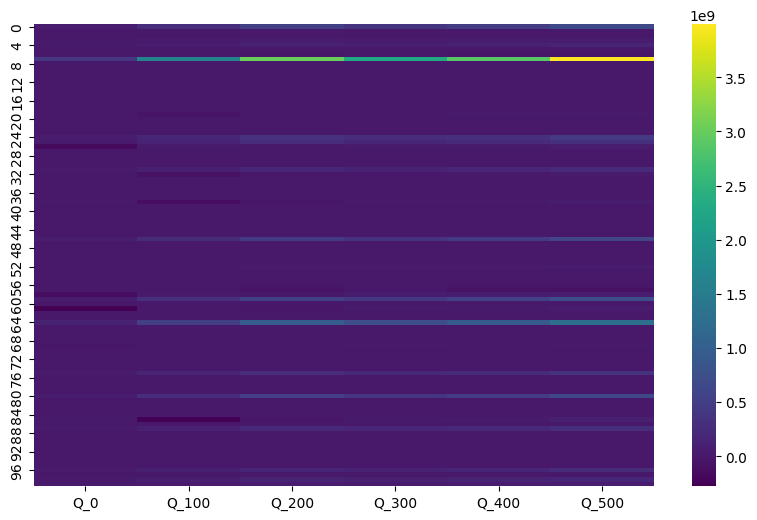

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    q_df[
        [
            "Q_0",
            "Q_100",
            "Q_200",
            "Q_300",
            "Q_400",
            "Q_500"
        ]
    ],
    cmap="viridis"
)

plt.show()

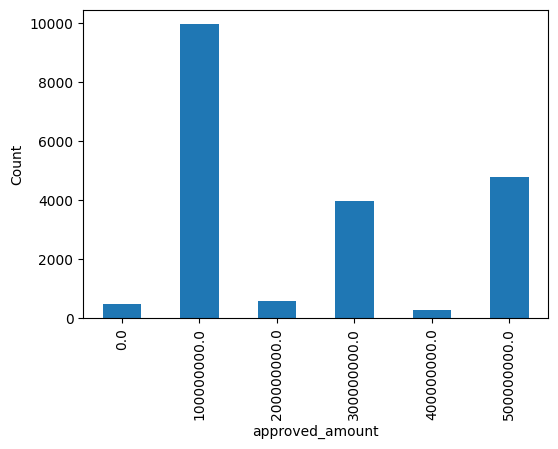

In [ ]:
plt.figure(figsize=(6,4))

results["approved_amount"].value_counts().sort_index().plot.bar()

plt.ylabel("Count")

plt.show()

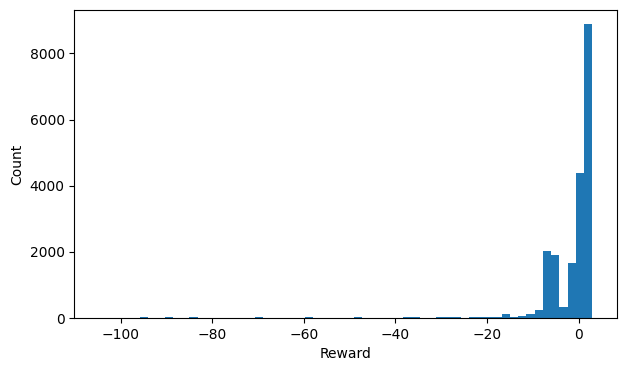

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(results.reward, bins=60)

plt.xlabel("Reward")

plt.ylabel("Count")

plt.show()

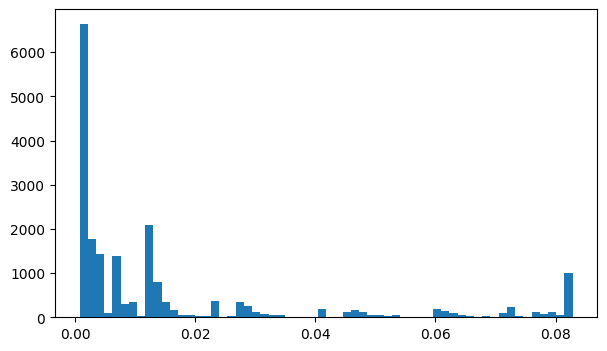

In [ ]:
plt.figure(figsize=(7,4))

plt.hist(
    results.probability_of_default,
    bins=60
)

plt.show()

In [ ]:
results["approved_amount"].value_counts().sort_index()

approved_amount
0.0             474
100000000.0    9956
200000000.0     571
300000000.0    3954
400000000.0     264
500000000.0    4782
Name: count, dtype: int64